In [3]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd

In [4]:
df = pd.read_csv("tmdb_movies_data.csv")

In [5]:
df.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/2015,5562,6.5,2015,137999939.3,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/2015,6185,7.1,2015,137999939.3,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/2015,2480,6.3,2015,101199955.5,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/2015,5292,7.5,2015,183999919.0,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/2015,2947,7.3,2015,174799923.1,1.385749e+09


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  str    
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  str    
 6   cast                  10790 non-null  str    
 7   homepage              2936 non-null   str    
 8   director              10822 non-null  str    
 9   tagline               8042 non-null   str    
 10  keywords              9373 non-null   str    
 11  overview              10862 non-null  str    
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  str    
 14  production_companies  9836 non-null   str    
 15  release_date          10866 no

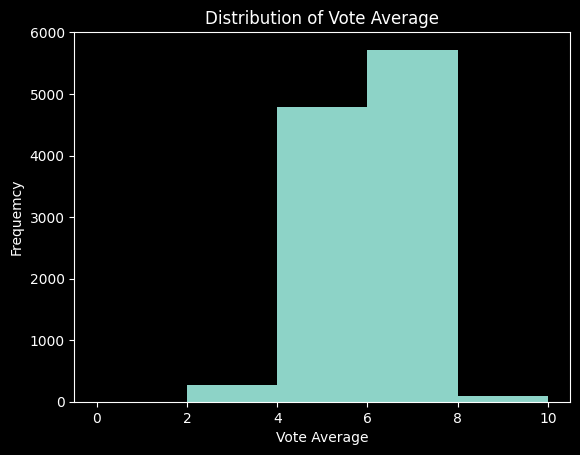

In [7]:
bins_num = [0, 2, 4, 6, 8, 10]
plt.hist(df["vote_average"],bins = bins_num);
plt.xlabel("Vote Average")
plt.ylabel("Frequemcy")
plt.title("Distribution of Vote Average")
plt.show()

In [8]:
movies_Count = pd.DataFrame(df.release_year.value_counts(ascending=True))
movies_Count

,count
release_year,
1961,31
1969,31
1962,32
1960,32
1963,34
1965,35
1968,39
1972,40
1967,40


In [9]:
movies_Count = movies_Count.reset_index()
movies_Count

,release_year,count
0,1961,31
1,1969,31
2,1962,32
3,1960,32
4,1963,34
5,1965,35
6,1968,39
7,1972,40
8,1967,40
9,1970,41


In [10]:
movies_Count.columns = ["Year","Count"]
movies_Count = movies_Count.sort_values(by=["Year"])
movies_Count

,Year,Count
3,1960,32
0,1961,31
2,1962,32
4,1963,34
10,1964,42
5,1965,35
12,1966,46
8,1967,40
6,1968,39
1,1969,31


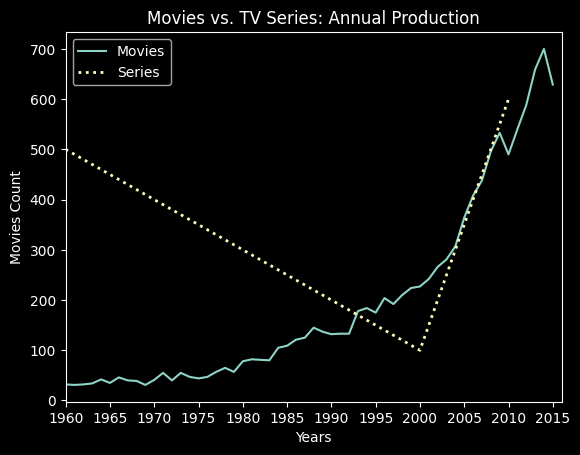

In [11]:
plt.plot(movies_Count["Year"], movies_Count["Count"]);
plt.plot(range(1960, 2015, 10),[500, 400, 300, 200, 100, 600], linestyle = ":", linewidth = 2);
plt.legend(["Movies","Series"])
plt.xlabel("Years")
plt.ylabel("Movies Count")
plt.title("Movies vs. TV Series: Annual Production")
plt.xlim(1960, 2016);
plt.xticks(range(1960, 2016, 5));

In [12]:
top_revenue = df.groupby("original_title").sum().sort_values(by="revenue", ascending=False)
top_revenue.head()

,id,imdb_id,popularity,budget,revenue,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
original_title,,,,,,,,,,,,,,,,,,,,
Avatar,19995,tt0499549,9.432768,237000000,2781505847,Sam Worthington|Zoe Saldana|Sigourney Weaver|S...,http://www.avatarmovie.com/,James Cameron,Enter the World of Pandora.,culture clash|future|space war|space colony|so...,"In the 22nd century, a paraplegic Marine is di...",162,Action|Adventure|Fantasy|Science Fiction,Ingenious Film Partners|Twentieth Century Fox ...,12/10/2009,8458,7.1,2009,2.408869e+08,2.827124e+09
Star Wars: The Force Awakens,140607,tt2488496,11.173104,200000000,2068178225,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,android|spaceship|jedi|space opera|3d,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/2015,5292,7.5,2015,1.839999e+08,1.902723e+09
Titanic,3296,tt0120338tt0115392,4.574583,213000000,1845034188,Kate Winslet|Leonardo DiCaprio|Frances Fisher|...,http://www.titanicmovie.com/menu.html,James CameronRobert Lieberman,Nothing on Earth could come between them.,shipwreck|iceberg|ship|panic|titanicshipwreck|...,"84 years later, a 101-year-old woman named Ros...",367,Drama|Romance|ThrillerAction|Drama|Romance,Paramount Pictures|Twentieth Century Fox Film ...,11/18/199711/17/1996,4675,13.4,3993,2.897649e+08,2.506406e+09
The Avengers,33748,tt0848228tt0118661,8.176900,280000000,1568080742,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,http://marvel.com/avengers_movie/,Joss WhedonJeremiah S. Chechik,Some assembly required.Saving the World in Style.,new york|shield|marvel comic|comic|superherolo...,When an unexpected enemy emerges and threatens...,232,Science Fiction|Action|AdventureThriller,Marvel StudiosJerry Weintraub Productions|Warn...,4/25/20128/13/1998,9024,11.9,4010,2.892055e+08,1.508100e+09
Jurassic World,135397,tt0369610,32.985763,150000000,1513528810,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/2015,5562,6.5,2015,1.379999e+08,1.392446e+09


In [13]:
movies = ["Avatar", "Star Wars", "Titanic", "The Avengers", "JW"]
revenue = top_revenue.head().revenue.values


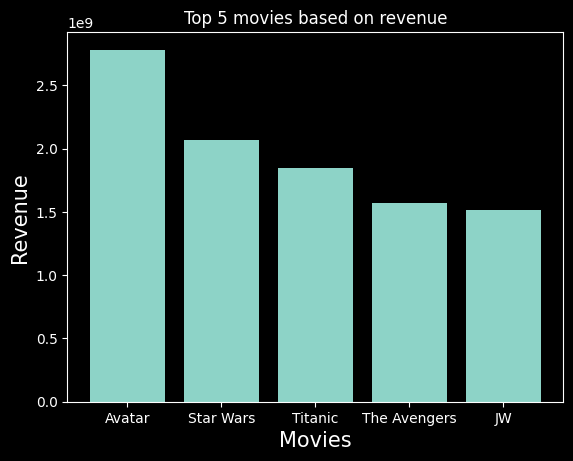

In [14]:
plt.bar(movies, revenue);
plt.xlabel("Movies", fontsize=15)
plt.ylabel("Revenue", fontsize=15)
plt.title("Top 5 movies based on revenue");

In [15]:
top_genres = df.groupby("genres").sum().sort_values(by="revenue", ascending=False)["revenue"][0:5]
top_genres

genres
Comedy                      20323889661
Drama                       15107533347
Comedy|Romance              11545724341
Adventure|Fantasy|Action     7597483556
Comedy|Drama|Romance         7251175696
Name: revenue, dtype: int64

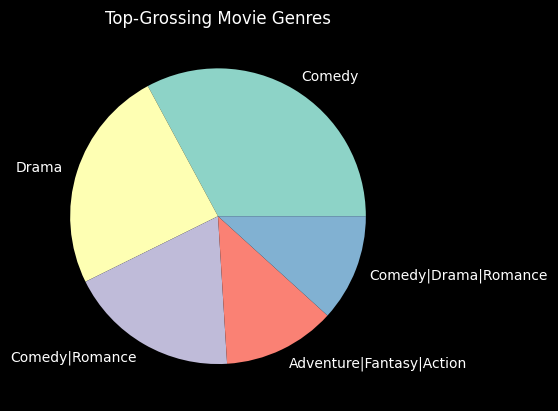

In [16]:
plt.pie(top_genres.values, labels = top_genres.index);
plt.title("Top-Grossing Movie Genres");

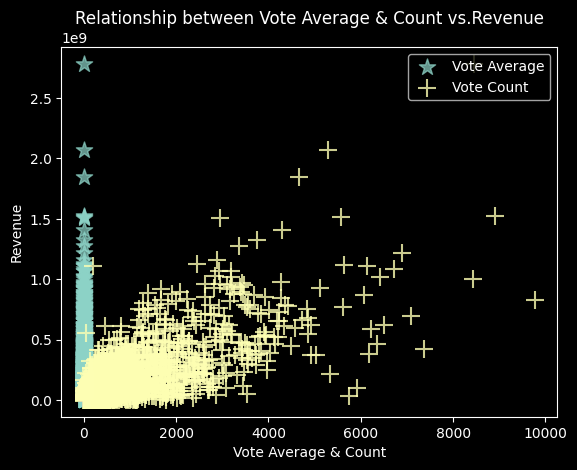

In [17]:
plt.scatter(df.vote_average,df.revenue, alpha = 0.7, marker ="*", s=150, label="Vote Average");
plt.scatter(df.vote_count,df.revenue, alpha = 0.8, marker ="+", s=150, label="Vote Count");
plt.legend(loc="upper right")
plt.xlabel("Vote Average & Count")
plt.ylabel("Revenue")
plt.title("Relationship between Vote Average & Count vs.Revenue");

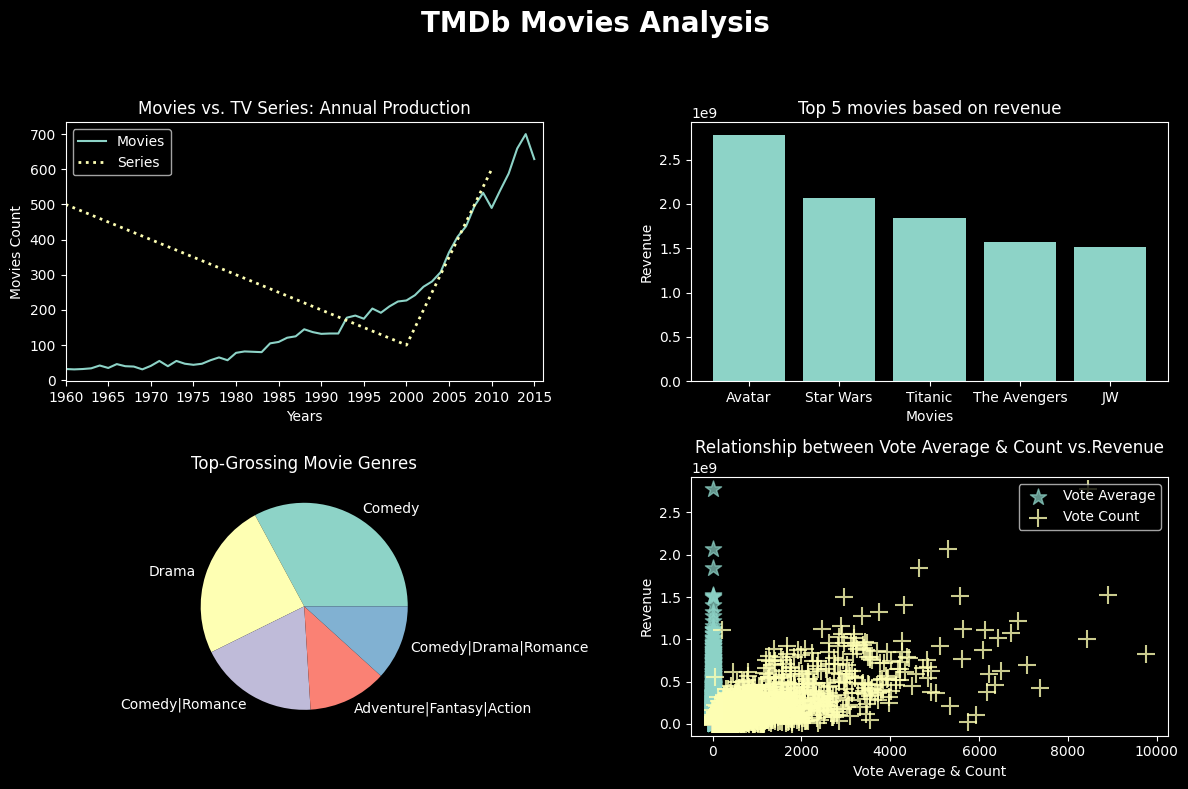

In [46]:
plt.figure(figsize=[12,8])
plt.suptitle("TMDb Movies Analysis", fontsize=20, fontweight="bold", y=0.98)

# First chart
plt.subplot(2, 2, 1)
plt.plot(movies_Count["Year"], movies_Count["Count"]);
plt.plot(range(1960, 2015, 10),[500, 400, 300, 200, 100, 600], linestyle = ":", linewidth = 2);
plt.legend(["Movies","Series"])
plt.xlabel("Years")
plt.ylabel("Movies Count")
plt.title("Movies vs. TV Series: Annual Production")
plt.xlim(1960, 2016);
plt.xticks(range(1960, 2016, 5));

# Second chart
plt.subplot(2, 2, 2)
plt.bar(movies, revenue);
plt.xlabel("Movies", fontsize=10)
plt.ylabel("Revenue", fontsize=10)
plt.title("Top 5 movies based on revenue");

# Third chart 
plt.subplot(2, 2, 3)
plt.pie(top_genres.values, labels = top_genres.index);
plt.title("Top-Grossing Movie Genres");

# Forth chart
plt.subplot(2, 2, 4)
plt.scatter(df.vote_average,df.revenue, alpha = 0.7, marker ="*", s=150, label="Vote Average");
plt.scatter(df.vote_count,df.revenue, alpha = 0.8, marker ="+", s=150, label="Vote Count");
plt.legend(loc="upper right")
plt.xlabel("Vote Average & Count")
plt.ylabel("Revenue")
plt.title("Relationship between Vote Average & Count vs.Revenue");

plt.tight_layout(rect=[0, 0, 1, 0.94])